In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_d3f664317277d45313b4ac026d37b849")

!chmod 600 /root/.kaggle/access_token
!pip install -q kaggle

In [ ]:
!kaggle competitions list


ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
!kaggle competitions download -c acea-water-prediction
!unzip -q acea-water-prediction.zip -d acea_data

acea-water-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
replace acea_data/Aquifer_Auser.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os
os.listdir("acea_data")


['datasets_description.xlsx',
 'Aquifer_Petrignano.csv',
 'Aquifer_Auser.csv',
 'Aquifer_Luco.csv',
 'Aquifer_Doganella.csv',
 'Water_Spring_Amiata.csv',
 'River_Arno.csv',
 'Lake_Bilancino.csv',
 'datasets_description.ods',
 'Water_Spring_Madonna_di_Canneto.csv',
 'Water_Spring_Lupa.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("acea_data/River_Arno.csv")
print(df.shape)
df.head()

(8217, 17)


,Date,Rainfall_Le_Croci,Rainfall_Cavallina,Rainfall_S_Agata,Rainfall_Mangona,Rainfall_S_Piero,Rainfall_Vernio,Rainfall_Stia,Rainfall_Consuma,Rainfall_Incisa,Rainfall_Montevarchi,Rainfall_S_Savino,Rainfall_Laterina,Rainfall_Bibbiena,Rainfall_Camaldoli,Temperature_Firenze,Hydrometry_Nave_di_Rosano
0,01/01/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.82
1,02/01/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.94
2,03/01/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.11
3,04/01/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.84
4,05/01/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.88


In [ ]:
# Convert Date column to actual datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Check overall date range
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

# Check how much missing data each column has
print("\nMissing values per column:")
print(df.isna().sum())

Start date: 1998-01-01 00:00:00
End date: 2020-06-30 00:00:00

Missing values per column:
Date                            0
Rainfall_Le_Croci            2191
Rainfall_Cavallina           2191
Rainfall_S_Agata             2191
Rainfall_Mangona             2191
Rainfall_S_Piero             2191
Rainfall_Vernio              3934
Rainfall_Stia                6934
Rainfall_Consuma             6934
Rainfall_Incisa              3649
Rainfall_Montevarchi         6570
Rainfall_S_Savino            6934
Rainfall_Laterina            6934
Rainfall_Bibbiena            5839
Rainfall_Camaldoli           6934
Temperature_Firenze          2025
Hydrometry_Nave_di_Rosano      48
dtype: int64


In [ ]:
# Keep only the columns with reliable long-term history
selected_cols = [
    'Date',
    'Rainfall_Le_Croci',
    'Rainfall_Cavallina',
    'Rainfall_S_Agata',
    'Rainfall_Mangona',
    'Rainfall_S_Piero',
    'Temperature_Firenze',
    'Hydrometry_Nave_di_Rosano'
]

df_clean = df[selected_cols].copy()

# Filter to 2004 onwards, where these columns are populated
df_clean = df_clean[df_clean['Date'] >= '2004-01-01'].reset_index(drop=True)

print(df_clean.shape)
print("\nMissing values per column:")
print(df_clean.isna().sum())

df_clean.head()

(6026, 8)

Missing values per column:
Date                            0
Rainfall_Le_Croci               0
Rainfall_Cavallina              0
Rainfall_S_Agata                0
Rainfall_Mangona                0
Rainfall_S_Piero                0
Temperature_Firenze          1082
Hydrometry_Nave_di_Rosano       3
dtype: int64


,Date,Rainfall_Le_Croci,Rainfall_Cavallina,Rainfall_S_Agata,Rainfall_Mangona,Rainfall_S_Piero,Temperature_Firenze,Hydrometry_Nave_di_Rosano
0,2004-01-01,0.0,0.0,0.4,0.0,0.0,8.65,1.84
1,2004-01-02,0.0,0.0,0.0,0.0,0.0,7.10,1.93
2,2004-01-03,0.0,0.0,0.0,0.0,0.0,5.50,1.61
3,2004-01-04,0.0,0.0,0.0,0.0,0.0,3.55,1.35
4,2004-01-05,0.0,0.0,0.0,0.0,0.2,2.70,1.44


In [ ]:
# Check where temperature is missing - one big gap, or scattered?
missing_temp = df_clean[df_clean['Temperature_Firenze'].isna()]
print("First missing date:", missing_temp['Date'].min())
print("Last missing date:", missing_temp['Date'].max())
print("Number of missing rows:", len(missing_temp))

# Visualize as a simple check: count missing per year
df_clean['year'] = df_clean['Date'].dt.year
print("\nMissing temperature count per year:")
print(df_clean[df_clean['Temperature_Firenze'].isna()].groupby('year').size())


First missing date: 2004-04-16 00:00:00
Last missing date: 2020-06-30 00:00:00
Number of missing rows: 1082

Missing temperature count per year:
year
2004      1
2007      5
2016     10
2017    154
2018    365
2019    365
2020    182
dtype: int64


In [ ]:
# Drop temperature - too much missing data in later years
df_final = df_clean.drop(columns=['Temperature_Firenze', 'year'])

# Handle the 3 missing hydrometry values via simple interpolation (safe - very few, short gaps)
df_final['Hydrometry_Nave_di_Rosano'] = df_final['Hydrometry_Nave_di_Rosano'].interpolate()

print(df_final.shape)
print("\nMissing values per column:")
print(df_final.isna().sum())

df_final.head()

(6026, 7)

Missing values per column:
Date                         0
Rainfall_Le_Croci            0
Rainfall_Cavallina           0
Rainfall_S_Agata             0
Rainfall_Mangona             0
Rainfall_S_Piero             0
Hydrometry_Nave_di_Rosano    0
dtype: int64


,Date,Rainfall_Le_Croci,Rainfall_Cavallina,Rainfall_S_Agata,Rainfall_Mangona,Rainfall_S_Piero,Hydrometry_Nave_di_Rosano
0,2004-01-01,0.0,0.0,0.4,0.0,0.0,1.84
1,2004-01-02,0.0,0.0,0.0,0.0,0.0,1.93
2,2004-01-03,0.0,0.0,0.0,0.0,0.0,1.61
3,2004-01-04,0.0,0.0,0.0,0.0,0.0,1.35
4,2004-01-05,0.0,0.0,0.0,0.0,0.2,1.44


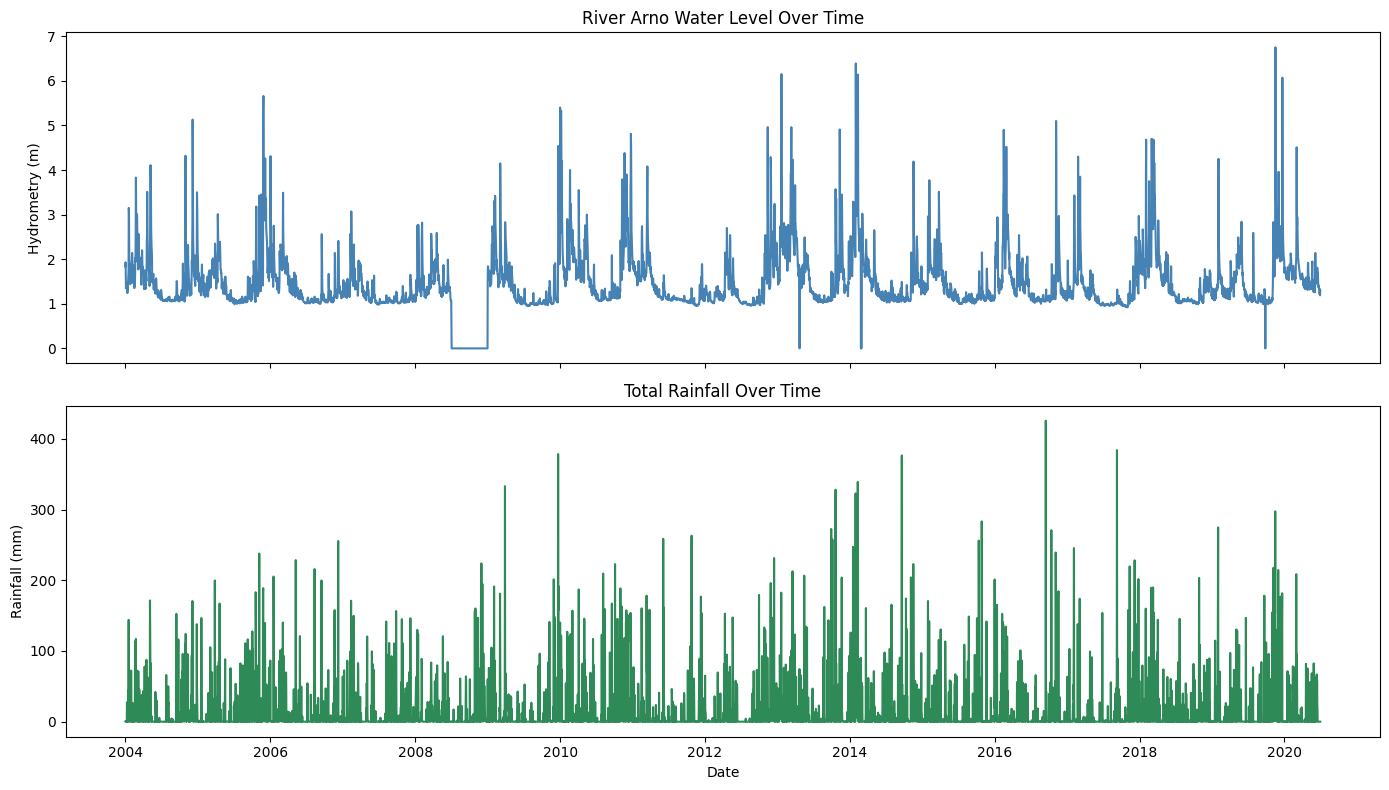

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot water level over time
axes[0].plot(df_final['Date'], df_final['Hydrometry_Nave_di_Rosano'], color='steelblue')
axes[0].set_title('River Arno Water Level Over Time')
axes[0].set_ylabel('Hydrometry (m)')

# Plot total daily rainfall (sum across stations) over time
rainfall_cols = ['Rainfall_Le_Croci', 'Rainfall_Cavallina', 'Rainfall_S_Agata', 'Rainfall_Mangona', 'Rainfall_S_Piero']
df_final['Total_Rainfall'] = df_final[rainfall_cols].sum(axis=1)

axes[1].plot(df_final['Date'], df_final['Total_Rainfall'], color='seagreen')
axes[1].set_title('Total Rainfall Over Time')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Features: all rainfall columns + water level itself (helps model learn from recent levels too)
feature_cols = ['Rainfall_Le_Croci', 'Rainfall_Cavallina', 'Rainfall_S_Agata',
                'Rainfall_Mangona', 'Rainfall_S_Piero', 'Hydrometry_Nave_di_Rosano']

data = df_final[feature_cols].values

# Scale everything to 0-1 range (LSTMs train much better on scaled data)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Function to build sliding window sequences
def create_sequences(data, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, target_col_idx])
    return np.array(X), np.array(y)

WINDOW_SIZE = 7  # past 7 days
TARGET_COL_IDX = feature_cols.index('Hydrometry_Nave_di_Rosano')

X, y = create_sequences(data_scaled, WINDOW_SIZE, TARGET_COL_IDX)

print("X shape:", X.shape)  # (samples, window_size, features)
print("y shape:", y.shape)  # (samples,)

X shape: (6019, 7, 6)
y shape: (6019,)


In [ ]:
# Chronological split - no shuffling!
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (4213, 7, 6) (4213,)
Val:   (903, 7, 6) (903,)
Test:  (903, 7, 6) (903,)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Naive baseline: predict "today's level" (last day in the window) as tomorrow's level
# Since data is scaled, we work in scaled space for now, then also check in real units

def naive_baseline_preds(X, target_col_idx):
    # last day in each window, for the target feature
    return X[:, -1, target_col_idx]

naive_test_preds = naive_baseline_preds(X_test, TARGET_COL_IDX)

rmse_naive = np.sqrt(mean_squared_error(y_test, naive_test_preds))
mae_naive = mean_absolute_error(y_test, naive_test_preds)

print("Naive Baseline (scaled) - RMSE:", round(rmse_naive, 4), "| MAE:", round(mae_naive, 4))

Naive Baseline (scaled) - RMSE: 0.0497 | MAE: 0.0215


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

tf.random.set_seed(42)

gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(WINDOW_SIZE, X.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # predicting a single value: next day's water level
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 7, 64)          │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,777 (92.88 KB)

 Trainable params: 23,777 (92.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0044 - mae: 0.0420 - val_loss: 0.0019 - val_mae: 0.0288
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - mae: 0.0300 - val_loss: 0.0021 - val_mae: 0.0288
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - mae: 0.0269 - val_loss: 0.0018 - val_mae: 0.0256
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - mae: 0.0249 - val_loss: 0.0017 - val_mae: 0.0230
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0019 - mae: 0.0241 - val_loss: 0.0016 - val_mae: 0.0228
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0019 - mae: 0.0245 - val_loss: 0.0017 - val_mae: 0.0240
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0225 - val_loss: 0.0017 - val_mae: 0.0228
Epoch 8/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0228 - val_loss: 0.0015 - val_mae: 0.0198
Epoch 9/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/

In [ ]:
# Predict on test set
gru_test_preds = gru_model.predict(X_test).flatten()

rmse_gru = np.sqrt(mean_squared_error(y_test, gru_test_preds))
mae_gru = mean_absolute_error(y_test, gru_test_preds)

print("GRU Model (scaled)   - RMSE:", round(rmse_gru, 4), "| MAE:", round(mae_gru, 4))
print("Naive Baseline (scaled) - RMSE:", round(rmse_naive, 4), "| MAE:", round(mae_naive, 4))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
GRU Model (scaled)   - RMSE: 0.0419 | MAE: 0.0208
Naive Baseline (scaled) - RMSE: 0.0497 | MAE: 0.0215


In [ ]:
from tensorflow.keras.layers import LSTM

tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(WINDOW_SIZE, X.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0065 - mae: 0.0510 - val_loss: 0.0023 - val_mae: 0.0277
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0030 - mae: 0.0327 - val_loss: 0.0019 - val_mae: 0.0254
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - mae: 0.0303 - val_loss: 0.0018 - val_mae: 0.0247
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0023 - mae: 0.0279 - val_loss: 0.0018 - val_mae: 0.0227
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0021 - mae: 0.0261 - val_loss: 0.0019 - val_mae: 0.0239
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - mae: 0.0246 - val_loss: 0.0017 - val_mae: 0.0221
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0019 - mae: 0.0240 - val_loss: 0.0018 - val_mae: 0.0225
Epoch 8/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - mae: 0.0236 - val_loss: 0.0017 - val_mae: 0.0227
Epoch 9/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss

In [ ]:
lstm_test_preds = lstm_model.predict(X_test).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test, lstm_test_preds))
mae_lstm = mean_absolute_error(y_test, lstm_test_preds)

print("Final Comparison (scaled units):")
print(f"{'Model':<20}{'RMSE':<10}{'MAE':<10}")
print(f"{'Naive Baseline':<20}{rmse_naive:<10.4f}{mae_naive:<10.4f}")
print(f"{'GRU':<20}{rmse_gru:<10.4f}{mae_gru:<10.4f}")
print(f"{'LSTM':<20}{rmse_lstm:<10.4f}{mae_lstm:<10.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Final Comparison (scaled units):
Model               RMSE      MAE       
Naive Baseline      0.0497    0.0215    
GRU                 0.0419    0.0208    
LSTM                0.0413    0.0204    


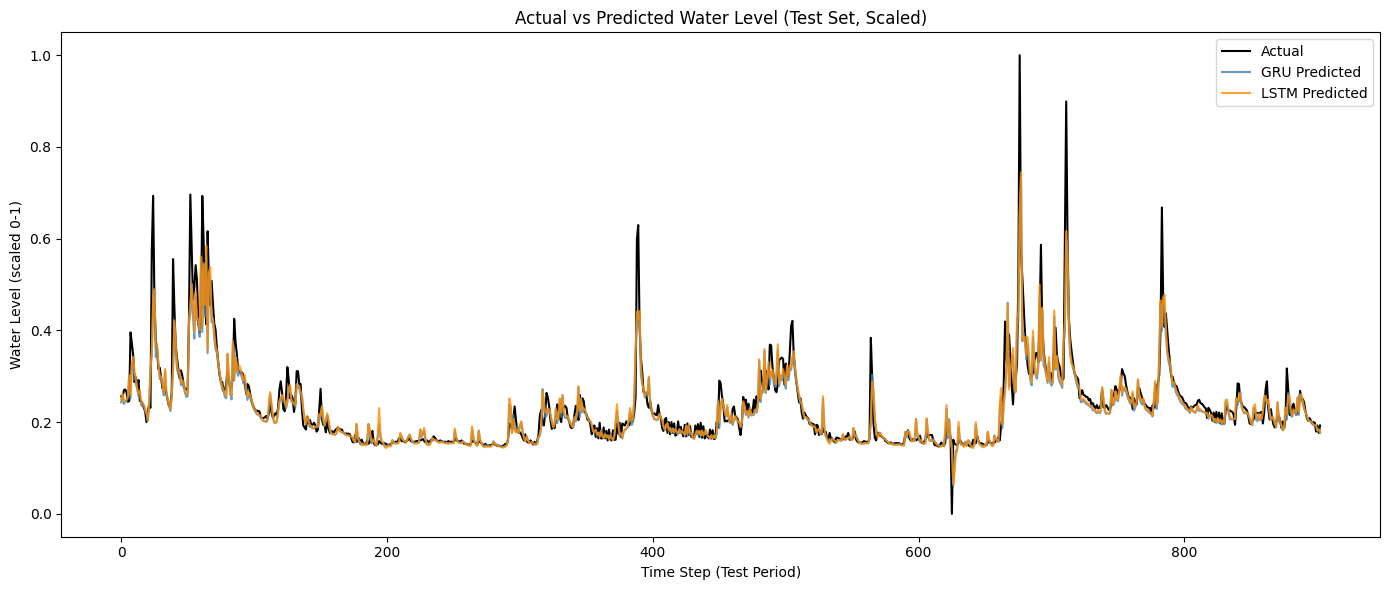

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual', color='black', linewidth=1.5)
plt.plot(gru_test_preds, label='GRU Predicted', color='steelblue', alpha=0.8)
plt.plot(lstm_test_preds, label='LSTM Predicted', color='darkorange', alpha=0.8)
plt.title('Actual vs Predicted Water Level (Test Set, Scaled)')
plt.xlabel('Time Step (Test Period)')
plt.ylabel('Water Level (scaled 0-1)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

# Get the dates corresponding to the test set targets, for labeling
test_start_idx = val_end + WINDOW_SIZE  # aligns with y_test indexing
test_dates = df_final['Date'].iloc[test_start_idx : test_start_idx + len(y_test)].reset_index(drop=True)

def predict_at_index(day_index):
    day_index = int(day_index)

    # Grab the actual window and true value
    window = X_test[day_index]  # shape (7, 6)
    actual = y_test[day_index]

    # Predict with both models
    gru_pred = gru_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]
    lstm_pred = lstm_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]

    date_label = test_dates.iloc[day_index].strftime('%Y-%m-%d')

    result = f"""
    ### Prediction for {date_label}

    **Actual water level (scaled):** {actual:.4f}
    **GRU predicted:** {gru_pred:.4f}
    **LSTM predicted:** {lstm_pred:.4f}
    """
    return result

demo = gr.Interface(
    fn=predict_at_index,
    inputs=gr.Slider(0, len(y_test)-1, step=1, label="Test Day Index"),
    outputs=gr.Markdown(),
    title="Flood Risk Forecaster - River Arno",
    description="Slide to pick a day in the test period (2019-2020) and see how GRU/LSTM predicted the next day's water level vs the actual value."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63591640bc0c80d8f6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


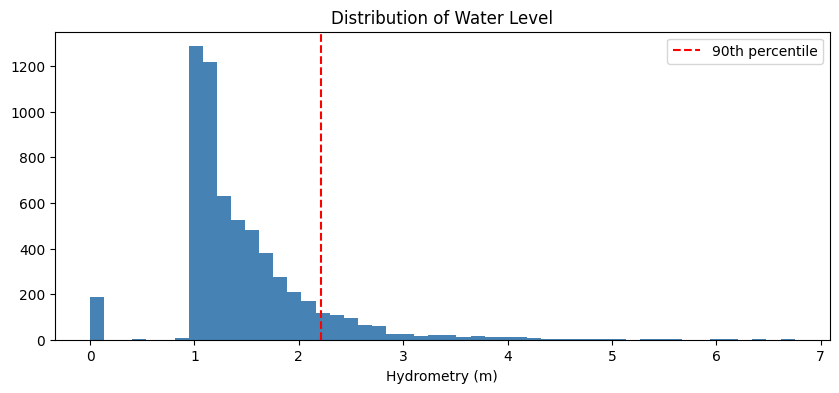

90th percentile level: 2.21
95th percentile level: 2.6


In [ ]:
# Look at the distribution of the (unscaled) water level to pick a sensible flood threshold
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df_final['Hydrometry_Nave_di_Rosano'], bins=50, color='steelblue')
plt.axvline(df_final['Hydrometry_Nave_di_Rosano'].quantile(0.90), color='red', linestyle='--', label='90th percentile')
plt.title('Distribution of Water Level')
plt.xlabel('Hydrometry (m)')
plt.legend()
plt.show()

print("90th percentile level:", df_final['Hydrometry_Nave_di_Rosano'].quantile(0.90))
print("95th percentile level:", df_final['Hydrometry_Nave_di_Rosano'].quantile(0.95))

In [ ]:
# Create binary flood labels based on hydrometry (unscaled)
FLOOD_THRESHOLD = df_final['Hydrometry_Nave_di_Rosano'].quantile(0.90)

df_final['Flood_Label'] = (df_final['Hydrometry_Nave_di_Rosano'] > FLOOD_THRESHOLD).astype(int)

print("Flood threshold (m):", round(FLOOD_THRESHOLD, 2))
print("\nClass balance:")
print(df_final['Flood_Label'].value_counts())
print(df_final['Flood_Label'].value_counts(normalize=True))

Flood threshold (m): 2.21

Class balance:
Flood_Label
0    5431
1     595
Name: count, dtype: int64
Flood_Label
0    0.901261
1    0.098739
Name: proportion, dtype: float64


In [ ]:
# Reuse the same scaled feature data, but now predict the FLOOD LABEL (not the raw water level)
flood_labels = df_final['Flood_Label'].values

def create_classification_sequences(data, labels, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(labels[i+window_size])  # label for the day AFTER the window
    return np.array(X), np.array(y)

X_clf, y_clf = create_classification_sequences(data_scaled, flood_labels, WINDOW_SIZE)

print("X_clf shape:", X_clf.shape)
print("y_clf shape:", y_clf.shape)

# Same chronological split as before
X_clf_train, y_clf_train = X_clf[:train_end], y_clf[:train_end]
X_clf_val, y_clf_val = X_clf[train_end:val_end], y_clf[train_end:val_end]
X_clf_test, y_clf_test = X_clf[val_end:], y_clf[val_end:]

print("Train:", X_clf_train.shape, "| Flood days in train:", y_clf_train.sum())
print("Val:  ", X_clf_val.shape, "| Flood days in val:  ", y_clf_val.sum())
print("Test: ", X_clf_test.shape, "| Flood days in test: ", y_clf_test.sum())

X_clf shape: (6019, 7, 6)
y_clf shape: (6019,)
Train: (4213, 7, 6) | Flood days in train: 439
Val:   (903, 7, 6) | Flood days in val:   64
Test:  (903, 7, 6) | Flood days in test:  92


In [ ]:
from tensorflow.keras.metrics import AUC

tf.random.set_seed(42)

clf_model = Sequential([
    GRU(64, activation='tanh', input_shape=(WINDOW_SIZE, X_clf.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # outputs probability of flood (0-1)
])

clf_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

# class_weight helps the model pay more attention to the rare flood class
class_weight = {0: 1.0, 1: (len(y_clf_train) - y_clf_train.sum()) / y_clf_train.sum()}
print("Class weights:", class_weight)

history_clf = clf_model.fit(
    X_clf_train, y_clf_train,
    validation_data=(X_clf_val, y_clf_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Class weights: {0: 1.0, 1: np.float64(8.596810933940775)}
Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6888 - auc: 0.8968 - loss: 0.8153 - val_accuracy: 0.9236 - val_auc: 0.9711 - val_loss: 0.1960
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8927 - auc: 0.9636 - loss: 0.4414 - val_accuracy: 0.9324 - val_auc: 0.9666 - val_loss: 0.1693
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9024 - auc: 0.9678 - loss: 0.4126 - val_accuracy: 0.9313 - val_auc: 0.9662 - val_loss: 0.1924
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9089 - auc: 0.9723 - loss: 0.3820 - val_accuracy: 0.9291 - val_auc: 0.9651 - val_loss: 0.1852
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9122 - auc: 0.9733 - loss: 0.3712 - val_accuracy: 0.9324 - val_auc: 0.9685 - val_loss: 0.1791
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9138 - auc: 0.9744 - loss: 0.3665 - val_accuracy: 0.9336 - val_auc: 0.9707 - val_loss: 0.1744
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Get predicted probabilities, then convert to 0/1 using 0.5 threshold
clf_test_probs = clf_model.predict(X_clf_test).flatten()
clf_test_preds = (clf_test_probs > 0.5).astype(int)

test_auc = roc_auc_score(y_clf_test, clf_test_probs)
print("Test AUC:", round(test_auc, 4))

print("\nClassification Report:")
print(classification_report(y_clf_test, clf_test_preds, target_names=['No Flood', 'Flood']))

print("Confusion Matrix:")
print(confusion_matrix(y_clf_test, clf_test_preds))

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
Test AUC: 0.9786

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      0.93      0.96       811
       Flood       0.61      0.90      0.72        92

    accuracy                           0.93       903
   macro avg       0.80      0.92      0.84       903
weighted avg       0.95      0.93      0.94       903

Confusion Matrix:
[[757  54]
 [  9  83]]


In [ ]:
print(gru_model)

<Sequential name=sequential, built=True>


In [ ]:
import gradio as gr

def predict_at_index(day_index):
    day_index = int(day_index)

    # --- Regression predictions (water level) ---
    window = X_test[day_index]
    actual = y_test[day_index]

    gru_pred = gru_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]
    lstm_pred = lstm_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]

    # --- Classification prediction (flood yes/no) ---
    # Note: X_clf_test uses the same windows as X_test, so indices line up
    clf_window = X_clf_test[day_index]
    actual_flood_label = y_clf_test[day_index]

    flood_prob = clf_model.predict(clf_window.reshape(1, WINDOW_SIZE, X_clf.shape[2]), verbose=0)[0][0]
    flood_alert = "🚨 FLOOD RISK" if flood_prob > 0.5 else "✅ No Flood Risk"
    actual_flood_text =

SyntaxError: invalid syntax (724927047.py, line 20)

In [ ]:
import gradio as gr

def predict_at_index(day_index):
    day_index = int(day_index)

    window = X_test[day_index]
    actual = y_test[day_index]

    gru_pred = gru_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]
    lstm_pred = lstm_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]

    clf_window = X_clf_test[day_index]
    actual_flood_label = y_clf_test[day_index]

    flood_prob = clf_model.predict(clf_window.reshape(1, WINDOW_SIZE, X_clf.shape[2]), verbose=0)[0][0]

    if flood_prob > 0.5:
        flood_alert = "FLOOD RISK"
    else:
        flood_alert = "No Flood Risk"

    if actual_flood_label == 1:
        actual_flood_text = "Flood"
    else:
        actual_flood_text = "No Flood"

    date_label = test_dates.iloc[day_index].strftime('%Y-%m-%d')

    result = "### Prediction for " + date_label + "\n\n"
    result += "**Water Level (scaled)** — Actual: " + str(round(actual, 4))
    result += " | GRU: " + str(round(float(gru_pred), 4))
    result += " | LSTM: " + str(round(float(lstm_pred), 4)) + "\n\n"
    result += "**Flood Alert** — Model says: " + flood_alert
    result += " (probability: " + str(round(float(flood_prob) * 100, 1)) + "%)\n\n"
    result += "**Actual outcome:** " + actual_flood_text

    return result

demo = gr.Interface(
    fn=predict_at_index,
    inputs=gr.Slider(0, len(y_test)-1, step=1, label="Test Day Index"),
    outputs=gr.Markdown(),
    title="Flood Risk Forecaster - River Arno",
    description="Slide to pick a day in the

SyntaxError: unterminated string literal (detected at line 44) (986091370.py, line 44)

In [ ]:
import gradio as gr

def predict_at_index(day_index):
    day_index = int(day_index)

    window = X_test[day_index]
    actual = y_test[day_index]

    gru_pred = gru_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]
    lstm_pred = lstm_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]

    clf_window = X_clf_test[day_index]
    actual_flood_label = y_clf_test[day_index]

    flood_prob = clf_model.predict(clf_window.reshape(1, WINDOW_SIZE, X_clf.shape[2]), verbose=0)[0][0]

    if flood_prob > 0.5:
        flood_alert = "FLOOD RISK"
    else:
        flood_alert = "No Flood Risk"

    if actual_flood_label == 1:
        actual_flood_text = "Flood"
    else:
        actual_flood_text = "No Flood"

    date_label = test_dates.iloc[day_index].strftime('%Y-%m-%d')

    result = "### Prediction for " + date_label + "\n\n"
    result += "**Water Level (scaled)** — Actual: " + str(round(actual, 4))
    result += " | GRU: " + str(round(float(gru_pred), 4))
    result += " | LSTM: " + str(round(float(lstm_pred), 4)) + "\n\n"
    result += "**Flood Alert** — Model says: " + flood_alert
    result += " (probability: " + str(round(float(flood_prob) * 100, 1)) + "%)\n\n"
    result += "**Actual outcome:** " + actual_flood_text

    return result

demo = gr.Interface(
    fn=predict_at_index,
    inputs=gr.Slider(0, len(y_test)-1, step=1, label="Test Day Index"),
    outputs=gr.Markdown(),
    title="Flood Risk Forecaster - River Arno",
    description="Slide to pick a day in the test period. See GRU/LSTM water level predictions AND the flood risk yes/no alert."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://03f0b6d6cb42cf0013.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr

def predict_at_index(day_index, threshold):
    day_index = int(day_index)

    # --- Regression predictions (water level) ---
    window = X_test[day_index]
    actual = y_test[day_index]

    gru_pred = gru_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]
    lstm_pred = lstm_model.predict(window.reshape(1, WINDOW_SIZE, X.shape[2]), verbose=0)[0][0]

    # --- Classification prediction (flood yes/no) ---
    clf_window = X_clf_test[day_index]
    actual_flood_label = y_clf_test[day_index]

    flood_prob = clf_model.predict(clf_window.reshape(1, WINDOW_SIZE, X_clf.shape[2]), verbose=0)[0][0]
    flood_prob = float(flood_prob)

    if flood_prob > threshold:
        flood_alert = "FLOOD RISK"
    else:
        flood_alert = "No Flood Risk"

    if actual_flood_label == 1:
        actual_flood_text = "Flood"
    else:
        actual_flood_text = "No Flood"

    date_label = test_dates.iloc[day_index].strftime('%Y-%m-%d')

    result = "### Prediction for " + date_label + "\n\n"
    result += "**Water Level (scaled)** — Actual: " + str(round(actual, 4))
    result += " | GRU: " + str(round(float(gru_pred), 4))
    result += " | LSTM: " + str(round(float(lstm_pred), 4)) + "\n\n"
    result += "**Flood Alert (threshold = " + str(round(threshold, 2)) + ")** — Model says: " + flood_alert
    result += " (confidence: " + str(round(flood_prob * 100, 1)) + "%)\n\n"
    result += "**Actual outcome:** " + actual_flood_text

    return result

demo = gr.Interface(
    fn=predict_at_index,
    inputs=[
        gr.Slider(0, len(y_test)-1, step=1, label="Test Day Index"),
        gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Flood Alert Threshold (lower = more alerts, more false alarms)")
    ],
    outputs=gr.Markdown(),
    title="Flood Risk Forecaster - River Arno",
    description="Pick a day, then adjust the threshold to see the trade-off between catching floods and avoiding false alarms."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://619a2e454a84b3c4ab.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np

flood_indices = np.where(y_clf_test == 1)[0]
print("Number of real flood days in test set:", len(flood_indices))
print("Test day indices where actual flood occurred:")
print(flood_indices)

Number of real flood days in test set: 92
Test day indices where actual flood occurred:
[  7   8   9  23  24  25  26  27  39  40  41  42  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  85
  86  87 388 389 390 391 488 489 495 496 497 498 503 504 505 506 564 665
 666 668 669 675 676 677 678 679 680 681 687 688 689 690 691 692 693 694
 695 702 703 704 705 710 711 712 713 714 715 716 782 783 784 785 786 787
 788 789]


In [ ]:
import numpy as np

# Real flood days (actual = 1)
flood_indices = np.where(y_clf_test == 1)[0]
print("Real FLOOD days (actual = 1):", len(flood_indices))
print(flood_indices)

print()

# Real no-flood days (actual = 0)
no_flood_indices = np.where(y_clf_test == 0)[0]
print("Real NO-FLOOD days (actual = 0):", len(no_flood_indices))
print(no_flood_indices[:20], "... (showing first 20 of", len(no_flood_indices), ")")

Real FLOOD days (actual = 1): 92
[  7   8   9  23  24  25  26  27  39  40  41  42  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  85
  86  87 388 389 390 391 488 489 495 496 497 498 503 504 505 506 564 665
 666 668 669 675 676 677 678 679 680 681 687 688 689 690 691 692 693 694
 695 702 703 704 705 710 711 712 713 714 715 716 782 783 784 785 786 787
 788 789]

Real NO-FLOOD days (actual = 0): 811
[ 0  1  2  3  4  5  6 10 11 12 13 14 15 16 17 18 19 20 21 22] ... (showing first 20 of 811 )
